# Phase Mapping

Phase mapping represents the local stage of an electrical cycle as an angle. This tutorial follows atrial excitation, reconstructs phase from transmembrane voltage, and identifies candidate spiral-wave cores through phase singularities.

## 1. Atrial excitation

### 1.1. Atrial geometry

The atrial surface provides the setting for wave propagation. A path between two selected points near the left superior pulmonary vein (LSPV) defines a reference for the initial excitation pattern.

Calculating the Geodesic Path: 100%|██████████[00:00<00:00]


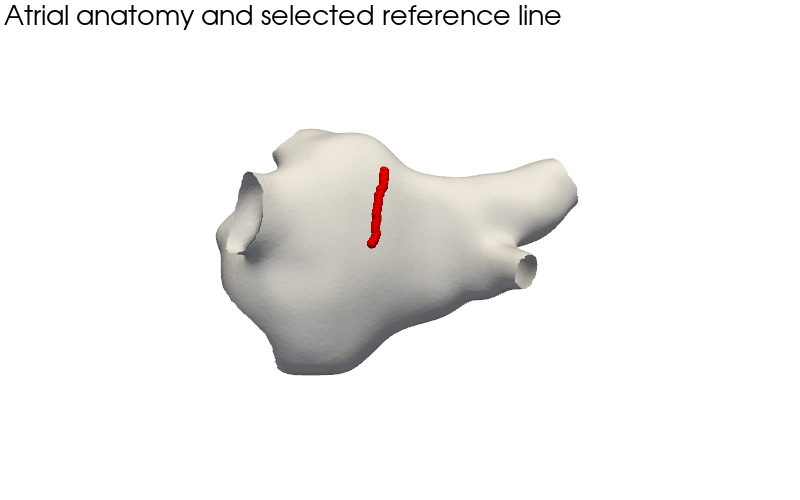

In [1]:
from pathlib import Path
import numpy as np
import pyvista as pv
import finitewave_tools.visualization as fwv


path = Path("./")

points = np.load(path / "data/atrial_points.npy")
elems = np.load(path / "data/atrial_elems.npy")

point_0_id = 3700
point_1_id = 7652
camera_position = "xz"

poly = fwv.PyVistaSurfaceGrid(points, elems)
poly_connection = poly.geodesic(point_0_id, point_1_id, progress_bar=True)
connection_ids = poly_connection.point_data["vtkOriginalPointIds"]

pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(800, 500))
pl.set_background("white")
pl.add_text("Atrial anatomy and selected reference line", position="upper_left", font_size=16, color="black")
pl.add_mesh(poly, color="white", opacity=1., show_edges=False)
pl.add_points(points[connection_ids], color="red", point_size=10, render_points_as_spheres=True)
pl.camera_position = camera_position
pl.show()


### 1.2. Initial excitation pattern

A signed coordinate around the pulmonary vein separates regions assigned to different stages of excitation and recovery. This spatial variation creates the initial conditions for reentrant propagation. The coordinate is a geometric construction, distinct from the electrical phase calculated later.

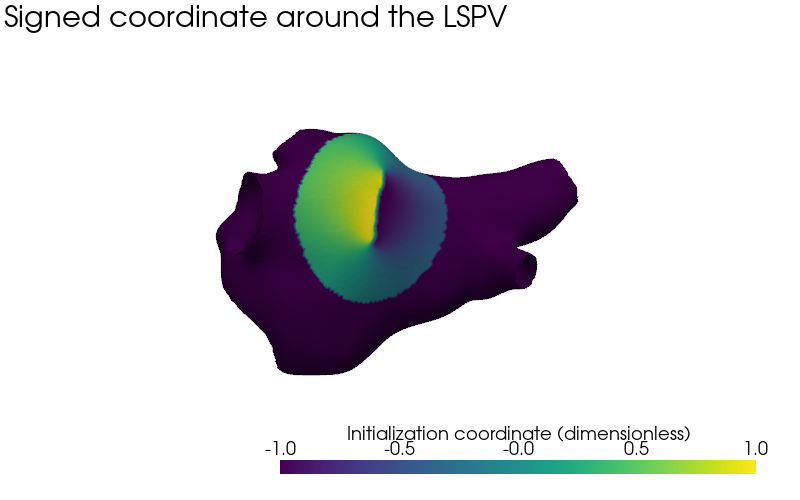

In [2]:
import numpy as np
import finitewave as fw
from finitewave_tools import linalg as fwlinalg


tissue = fw.CardiacTissueElements(points, elems, elem_type=fw.ElementType.TRIANGLE)

spatial_discretization = fw.FiniteElementDiscretization()
K, M = spatial_discretization.compute_weights(tissue)

areas = spatial_discretization.compute_element_sizes(points, elems)
G = spatial_discretization.build_gradient_operator(points, elems, as_sparse=False)

point_vec = fwlinalg.distance_direction(K, M, G, elems, point_0_id)
circ_vec = fwlinalg.distance_direction(K, M, G, elems, connection_ids)
circ_normal = poly.cell_normals
circ_cross = np.cross(circ_vec, circ_normal)

dot_product = np.einsum('ij,ij->i', circ_cross, point_vec)
poly["dot_product"] = dot_product
poly = poly.cell_data_to_point_data(pass_cell_data=True)
phase = poly.point_data["dot_product"]

circ_dist = fwlinalg.geodesic_distance(K, M, G, elems, areas, connection_ids)
phase[circ_dist > 20] = -1

pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(800, 500))
pl.set_background("white")
pl.add_text("Signed coordinate around the LSPV", position="upper_left", font_size=16, color="black")
pl.add_mesh(poly, scalars=phase, cmap="viridis", opacity=1,
            scalar_bar_args={"title": "Initialization coordinate (dimensionless)",
                             "color": "black", "n_labels": 5, "fmt": "%.1f"})
pl.camera_position = camera_position
pl.show()

### 1.3. Atrial cell dynamics

The Courtemanche–Ramirez–Nattel model describes human atrial action potentials through ionic currents and intracellular state variables [1]. Here, modified ionic parameters represent a remodeled atrial setting. Repeated pacing prepares the cell state before different stages of the action potential are distributed across the atrial surface.

Running Courtemanche on (50, 1) Grid:   0%|          | 0/30000 [00:00<?, ?it/s]

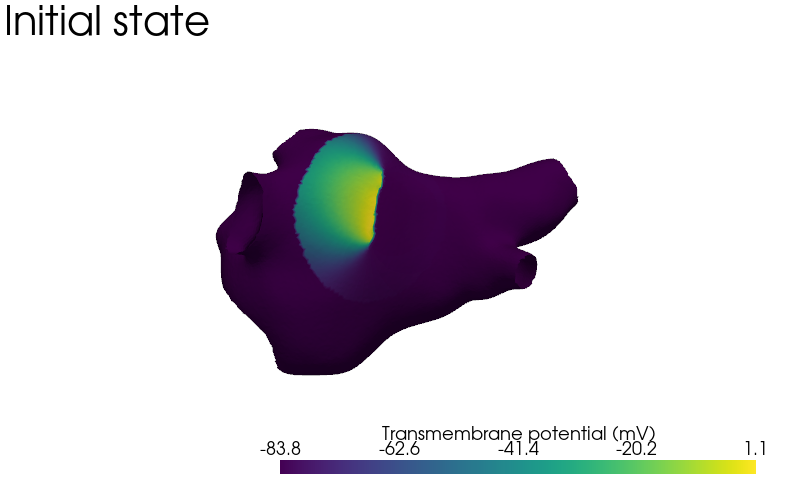

In [3]:

import numpy as np
import pyvista as pv

import finitewave as fw
import numpy as np


remodeled_params =dict(
    gk1 = 2 * 0.09,
    gks = 2 * 0.129,
    gkr = 1.6 * 0.0294,
    gkur = 0.5 * 1.0,
    gcal = 0.45 * 0.1238,
    gto = 0.35 * 0.1652,
    ipcamax = 1.5 * 0.6,
    inacamax = 1.6 * 1600.0
)

stim_prepacing = fw.StimSingleCell(dt=0.01)
stim_prepacing.add_stim(n_beats=100, cycle_length=1000, duration=1, curr_value=0.5)
stim_prepacing.add_stim(n_beats=100, cycle_length=500, duration=1, curr_value=0.5)

cardiac_model = fw.Courtemanche()
cardiac_model.set_parameters(remodeled_params)
cardiac_model.prepacing(stim_prepacing)

# create a tissue of size 50x1 to collect the state variables.
n, m = 50, 1
tissue = fw.CardiacTissue([n, m], dr=0.25)

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimCurrentCoord(time=0, curr_value=100, duration=2,
                                           x_min=0, x_max=1, y_min=0, y_max=m))

state_tracker = fw.MultiVariableTracker(node_inds=[(n//2, m//2)], step=10, start_time=0)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(state_tracker)

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.01, t_max=300, backend="numba")

simulation.cardiac_model = cardiac_model
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.tracker_sequence = tracker_sequence

# run the model:
simulation.run()

state_vars = {}
n_levels = len(state_tracker.tracking_times[120:])
state_map = n_levels - np.digitize(phase, bins=np.linspace(-1, 1, n_levels))
for var_name in cardiac_model.state_vars:
    tracked_values = state_tracker.output[var_name][120:]
    var_array = tracked_values[state_map]
    state_vars[var_name] = var_array


pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(800, 500))
pl.set_background("white")
pl.add_text("Initial state", position="upper_left", font_size=16, color="black")
pl.add_mesh(poly, scalars=state_vars["u"], cmap="viridis", opacity=1,
            scalar_bar_args={"title": "Transmembrane potential (mV)",
                             "color": "black", "n_labels": 5, "fmt": "%.1f"})
pl.camera_position = camera_position
pl.show()


### 1.4. Wave propagation

Electrical coupling spreads excitation between neighboring regions while local ionic currents govern activation and recovery. The resulting voltage recording captures the evolution of the reentrant wave and provides the signal for phase analysis.

Running Courtemanche on Triangle Elements:   0%|          | 0/50000 [00:00<?, ?it/s]

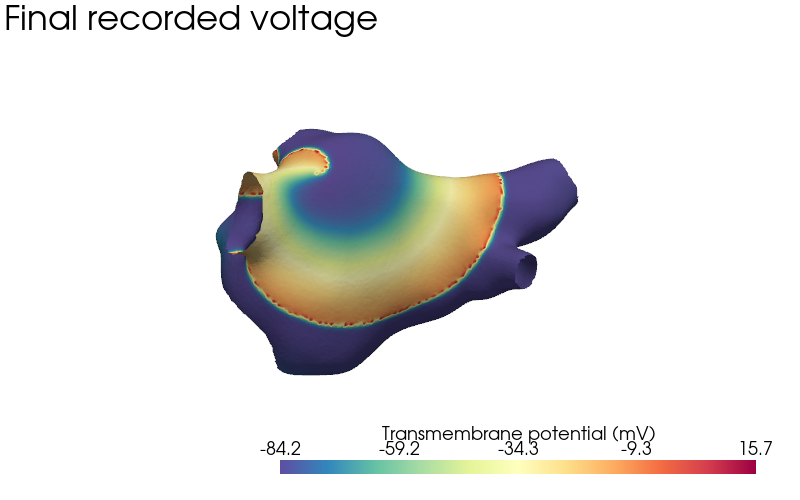

In [12]:
cardiac_model = fw.Courtemanche()
cardiac_model.set_parameters(remodeled_params)
cardiac_model.prepacing(stim_prepacing)
cardiac_model.set_variables(state_vars)

frame_tracker = fw.FrameTracker(aggregate=True, step=50, start_time=300)

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.02, t_max=1000, backend="jax")
# add the tissue and the stim parameters to the model object:
simulation.cardiac_tissue = fw.CardiacTissue(coords=points, elems=elems,
                                             elem_type=fw.ElementType.TRIANGLE)
simulation.cardiac_model = cardiac_model
# set up time integration:
simulation.time_integration = fw.BackwardEulerTimeIntegration(atol=1e-6, maxiter=100, lumping_factor=1.0, reaction_lumping=True)
simulation.tracker_sequence = fw.TrackerSequence()
simulation.tracker_sequence.add_tracker(frame_tracker)

# run the model:
simulation.run()

# get the resulting potential at the element centers:
sample_times = frame_tracker.tracking_times
frames = frame_tracker.frames[:len(sample_times)]

u = frames[-1]

pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(800, 500))
pl.set_background("white")
pl.add_text("Final recorded voltage", position="upper_left", font_size=16, color="black")
pl.add_mesh(poly, scalars=u, cmap="Spectral_r", opacity=1,
            scalar_bar_args={"title": "Transmembrane potential (mV)",
                             "color": "black", "n_labels": 5, "fmt": "%.1f"})
pl.camera_position = camera_position
pl.show()

In [16]:
output_dir = path / "output"
output_dir.mkdir(parents=True, exist_ok=True)
np.save(output_dir / "atrial_spirals.npy", frames.astype(np.float32))
np.save(output_dir / "atrial_spirals_times.npy", sample_times)

## 2. Hilbert phase mapping

At each position $\mathbf{x}$, center the transmembrane voltage over the observation interval:

$$
v(\mathbf{x},t)=V(\mathbf{x},t)-\langle V(\mathbf{x},t)\rangle_t.
$$

The Hilbert transform supplies a complementary signal, allowing voltage to be represented by an amplitude and a phase [2]:

$$
z(\mathbf{x},t)=v(\mathbf{x},t)+i\mathcal{H}[v](\mathbf{x},t)
=A(\mathbf{x},t)e^{i\phi(\mathbf{x},t)},
$$

$$
A=|z|,\qquad
\phi=\arg z=\operatorname{atan2}\!\left(\mathcal{H}[v],v\right).
$$

Phase is expressed in radians between $-\pi$ and $\pi$. It is undefined when the analytic amplitude is zero and becomes sensitive to small perturbations when that amplitude is small.

In [17]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
import pyvista as pv
import finitewave_tools.visualization as fwv

# Works from either the repository root or the Tutorials directory.
path = Path(".") if Path("data/atrial_points.npy").exists() else Path("Tutorials")
frames = np.load(path / "output/atrial_spirals.npy", mmap_mode="r")
sample_times = np.load(path / "output/atrial_spirals_times.npy")
intervals = np.diff(sample_times)
elapsed_times = sample_times - sample_times[0]
print(f"{len(frames)} frames, {frames.shape[1]} nodes, dt = {intervals[0]:g} ms")

700 frames, 20000 nodes, dt = 1 ms


In [18]:
def hilbert_phase(voltage, batch_size=1024, amplitude_tolerance=1e-6):
    """Return phase (time, node); invalid/constant traces remain NaN.

    Transform the full time history in spatial batches to limit temporary
    memory. amplitude_tolerance is measured in the input voltage units (mV).
    """
    voltage = np.asarray(voltage)
    phase_frames = np.full(voltage.shape, np.nan, dtype=np.float32)
    
    for start in range(0, voltage.shape[1], batch_size):
        stop = min(start + batch_size, voltage.shape[1])
        traces = np.array(voltage[:, start:stop], dtype=np.float64, copy=True)
        valid = np.all(np.isfinite(traces), axis=0)
        traces[:, ~valid] = 0
        valid &= np.ptp(traces, axis=0) > amplitude_tolerance
        traces -= traces.mean(axis=0, keepdims=True)
        analytic = hilbert(traces, axis=0)
        phase = np.angle(analytic)
        phase[:, ~valid] = np.nan
        phase[np.abs(analytic) <= amplitude_tolerance] = np.nan
        phase_frames[:, start:stop] = phase
    return phase_frames


phase_frames = hilbert_phase(frames)
print("Phase array:", phase_frames.shape)

Phase array: (700, 20000)


### 2.1. Voltage and phase

Phase describes progress around an oscillation rather than the voltage itself. For an ideal centered cosine,

$$
v(t)=A\cos(\omega t),\qquad
z(t)=Ae^{i\omega t},\qquad
\phi(t)=\omega t\pmod{2\pi}.
$$

Zero phase then coincides with the voltage maximum. Cardiac action potentials are asymmetric, so their phase is not tied to a fixed activation threshold. The jump between $\pi$ and $-\pi$ represents the same angle and is not a discontinuity in the underlying voltage.

The shaded ends of the recording mark regions where finite-record effects may affect phase. Their width is illustrative, not an error bound.

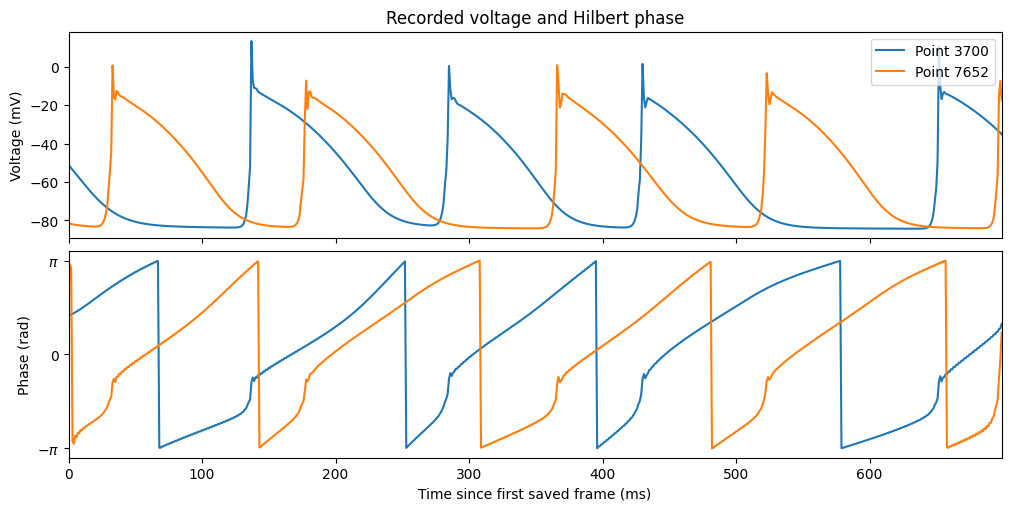

In [33]:
point_ids = [3700, 7652]
edge_margin_ms = 50.0
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, layout="constrained")
for node in point_ids:
    axes[0].plot(elapsed_times, frames[:, node], label=f"Point {node}")
    axes[1].plot(elapsed_times, phase_frames[:, node], label=f"Point {node}")
axes[0].set(ylabel="Voltage (mV)", title="Recorded voltage and Hilbert phase")
axes[0].legend()
axes[1].set(xlabel="Time since first saved frame (ms)", ylabel="Phase (rad)")
axes[1].set_yticks([-np.pi, 0, np.pi], [r"$-\pi$", "0", r"$\pi$"])
for ax in axes:
    ax.set_xlim(0, elapsed_times[-1])
plt.show()

### 2.2. Phase on the atrial surface

A phase map compares the stages of excitation across the atrium at one instant. Nearby regions with similar phase occupy similar parts of their electrical cycles. A cyclic color scale joins $-\pi$ and $\pi$ continuously; gray indicates undefined phase.

Viewing voltage and phase together helps relate the phase pattern to the propagating excitation wave.

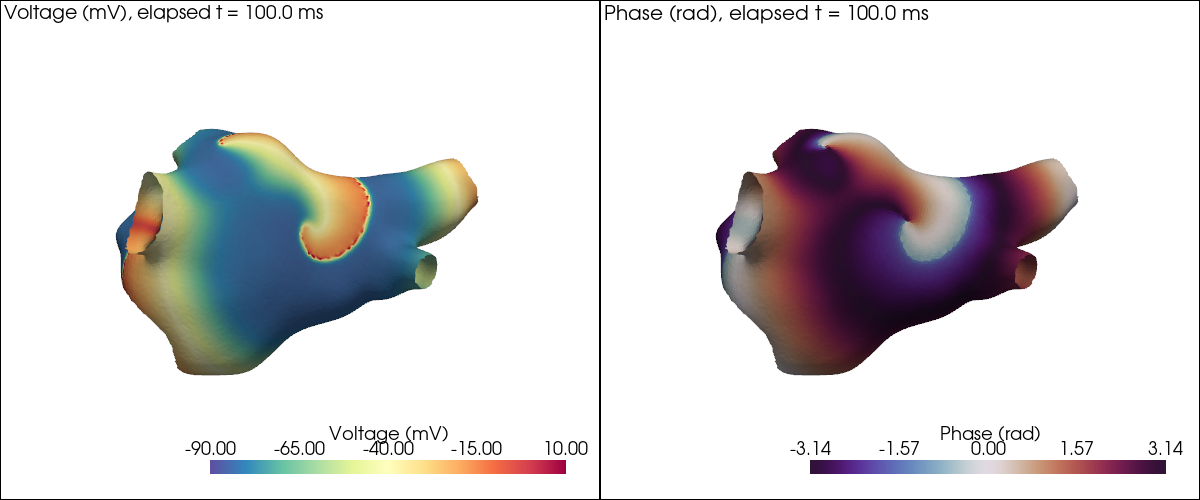

In [64]:
points = np.load(path / "data/atrial_points.npy")
elems = np.load(path / "data/atrial_elems.npy")


phase_surface = fwv.PyVistaSurfaceGrid(points, elems)
map_time_ms = float(elapsed_times[100])
frame_index = int(np.argmin(np.abs(elapsed_times - map_time_ms)))
phase_surface.point_data["voltage"] = np.asarray(frames[frame_index])
hilbert_phase = np.max(phase_frames[frame_index][elems], axis=1)

phase_surface.cell_data["hilbert_phase"] = hilbert_phase

pv.set_jupyter_backend("static")
pl = pv.Plotter(shape=(1, 2), window_size=(1200, 500))
for panel, scalar, cmap, limits, label in [
    (0, "voltage", "Spectral_r", (-90, 10), "Voltage (mV)"),
    (1, "hilbert_phase", "twilight_shifted", (-np.pi, np.pi), "Phase (rad)"),
]:
    pl.subplot(0, panel)
    pl.set_background("white")
    pl.add_text(f"{label}, elapsed t = {elapsed_times[frame_index]:.1f} ms",
                font_size=12, color="black")
    pl.add_mesh(phase_surface, scalars=scalar, preference="point", cmap=cmap,
                clim=limits, nan_color="lightgray",
                scalar_bar_args={"title": label, "color": "black", "fmt": "%.2f"})
    pl.camera_position = "xz"
pl.link_views()
pl.show()

## 3. Phase singularities

A phase singularity is a point around which phase completes a full turn while remaining undefined at the center. Such points can identify spiral-wave cores [3]. For a closed contour $C$, the winding number is

$$
q=\frac{1}{2\pi}\oint_C\nabla\phi\cdot d\boldsymbol{\ell}.
$$

On a triangular contour with phases $\phi_1,\phi_2,\phi_3$, the same measure is

$$
\Delta\phi_{ij}=\operatorname{Arg}\!\left(e^{i(\phi_j-\phi_i)}\right),
\qquad
q=\frac{\Delta\phi_{12}+\Delta\phi_{23}+\Delta\phi_{31}}{2\pi}.
$$

A winding number of $+1$ or $-1$ indicates a candidate singularity; zero indicates no net winding. The sign depends on the direction in which the contour is traversed.

The plots below collect detections across the recording, with color indicating time. These locations show where singularities occur, but do not establish individual trajectories or persistent rotors. Persistence and the surrounding voltage propagation should be checked before interpreting a detection as a rotor. Spatial resolution, low signal amplitude, and recording endpoints can affect detection.

Finding singularities:   0%|          | 0/700 [00:00<?, ?it/s]

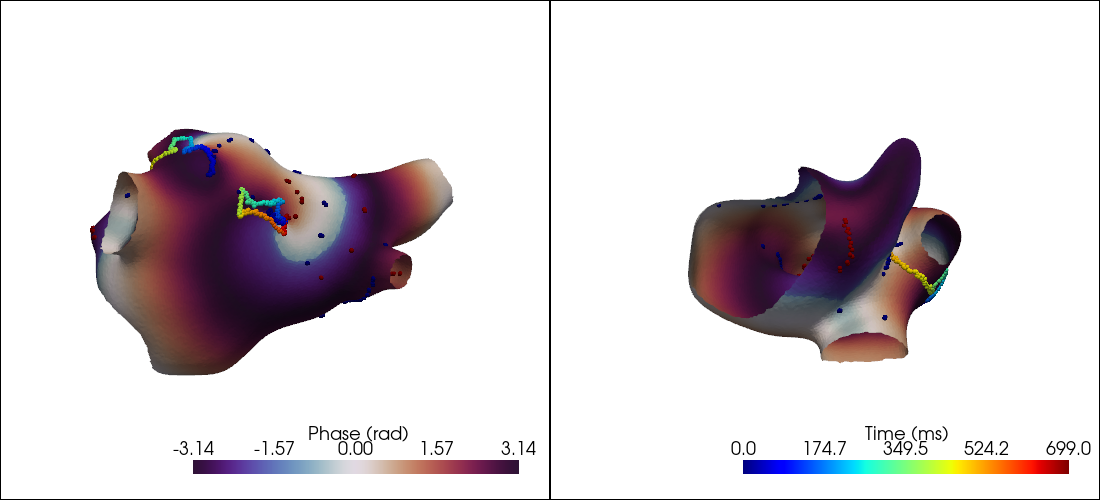

In [75]:
from tqdm.auto import tqdm


def compute_phase_singularities(points, triangles, vertex_phase, threshold=0.5):
    differences = np.roll(vertex_phase, -1, axis=1) - vertex_phase
    wrapped = np.angle(np.exp(1j * differences))
    winding = wrapped.sum(axis=1) / (2 * np.pi)

    valid = np.all(np.isfinite(vertex_phase), axis=1)
    singular = valid & (np.abs(winding) > threshold)

    singularity_positions = points[triangles[singular]].mean(axis=1)
    singularity_charges = np.sign(winding[singular]).astype(int)
    return singularity_positions, singularity_charges, np.where(singular)[0]


triangles = np.asarray(elems, dtype=int)

singularity_positions = []
singularity_times = []

for frame_index in tqdm(range(len(frames)), desc="Finding singularities"):
    phase = phase_frames[frame_index]
    vertex_phase = phase[triangles]

    singularities, _, _ = compute_phase_singularities(
        points, triangles, vertex_phase, threshold=0.5
    )
    singularity_positions.append(singularities)
    singularity_times.append(np.full(len(singularities), elapsed_times[frame_index]))

singularity_positions = np.concatenate(singularity_positions, axis=0)
singularity_times = np.concatenate(singularity_times, axis=0)


pl = pv.Plotter(shape=(1, 2), window_size=(1100, 500))
pl.subplot(0, 0)
pl.set_background("white")
pl.add_mesh(phase_surface, scalars="hilbert_phase", preference="point", cmap="twilight_shifted",
            clim=(-np.pi, np.pi), nan_color="lightgray",
            scalar_bar_args={"title": "Phase (rad)", "color": "black", "fmt": "%.2f"})
pl.add_points(
    singularity_positions, scalars=singularity_times, cmap="jet",
    point_size=5, render_points_as_spheres=True, show_scalar_bar=False
)
pl.camera_position = "xz"
pl.subplot(0, 1)
pl.set_background("white")
pl.add_mesh(phase_surface, scalars="hilbert_phase", preference="point", cmap="twilight_shifted",
            clim=(-np.pi, np.pi), nan_color="lightgray", show_scalar_bar=False)
pl.add_points(
    singularity_positions, scalars=singularity_times, cmap="jet",
    point_size=5, render_points_as_spheres=True,
    scalar_bar_args={"title": "Time (ms)", "color": "black", "fmt": "%.1f"},
)
pl.camera_position = "zy"
pl.show()

## 4. References

1. Courtemanche, M., Ramirez, R. J., and Nattel, S. (1998). [Ionic mechanisms underlying human atrial action potential properties: insights from a mathematical model](https://doi.org/10.1152/ajpheart.1998.275.1.H301). *American Journal of Physiology*, 275, H301–H321.
2. SciPy documentation. [Hilbert transform and analytic signal](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.hilbert.html).
3. Bray, M.-A., Lin, S.-F., Aliev, R. R., Roth, B. J., and Wikswo, J. P. (2001). [Experimental and theoretical analysis of phase singularity dynamics in cardiac tissue](https://doi.org/10.1046/j.1540-8167.2001.00716.x). *Journal of Cardiovascular Electrophysiology*, 12, 716–722.